In [95]:
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "Courier New"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

from transformers import AutoTokenizer

cuda


`pytorch` contains an `LSTM` network pre-baked. before using this pre-baked `LSTM` class, i consider developing my own module. an RNN improves on a FNN for problems which require knowledge of previous states, and/or include a time domain. they do this by sharing weights within a network across each 'iteration' (a day, a word, whatever). an LSTM has three main components:
- $c_{t-1}$: the cell state at recurrence $t-1$
- $h_{t-1}$: the hidden output at recurrence $t-1$
- $x_t$: the current input

thus, the output at recurrence $t$, $h_t$ is defined by $h_t = g(x_t, h_{t-1}, c_{t-1})$. within each cell, there exists a mechanism to *forget* previous cell state information and then *update* new cell state information into $c$. the cell state $c$ is shared within a layer across recurrences and is continually updated, thus for $N$ LSTM cells, there exists $N$ cell state variables.

In [2]:
class LSTMCell(nn.Module):
    def __init__(self, input_size: int, hidden_size: int):
        # construct the parent class
        super().__init__()
        
        # for the affine linear transformation of previous h and current x
        # 4 components x hidden_size values each
        # since y = XW + b where X = [batch_size, input_size] and W = [input_size * hidden_size]
        # thus when called, can handle a batch of N samples (with N * hidden_size output)
        self.x_trans = nn.Linear(input_size, 4 * hidden_size)
        self.h_trans = nn.Linear(hidden_size, 4 * hidden_size)

    def forward(self, x_curr: torch.Tensor, h_prev: torch.Tensor, c_prev: torch.Tensor):
        pre_gates: torch.Tensor = self.x_trans(x_curr) + self.h_trans(h_prev)

        # forget, input, update and output
        # forget: multiplies with the previous cell state; how much to forget
        # input: multiplier for the update
        # update: the actual value to update into the new cell state
        # output: the multipler for how much of the previous hidden state to carry forward
        fgt, inp, upd, out = pre_gates.chunk(4, dim=-1)

        fgt, inp, upd, out = torch.sigmoid(fgt), torch.sigmoid(inp), torch.tanh(upd), torch.sigmoid(out)

        c_curr = fgt * c_prev + inp * upd
        h_curr = out * torch.tanh(c_curr)

        return h_curr, c_curr

the above is good for just one recurrence at one cell, so we'll need a wrapper class to be able to accept an input $X \in \mathbb{R}^{M \times T}$ for $M$ features and $T$ recurrences. Since we wish to train on more than one sample, our input tensor will indeeed be three-dimensional $X_{train} \in \mathbb{R}^{N \times M \times T}$ for $N$ samples.

In [3]:
class LSTM(nn.Module):
    def __init__(self, input_size: int, hidden_size: int):
        super().__init__()

        self.hidden_size = hidden_size
        self.cell = LSTMCell(input_size, hidden_size)

    def forward(self, x: torch.Tensor):
        """
        x is a 3d tensor [batch_size, sequence_length, input_size]
        """
        batch_size = x.shape[0]
        sequence_length = x.shape[1]

        # each sequence (sample) requires a hidden state and cell state of size hidden size
        h = torch.zeros(batch_size, self.hidden_size, device = x.device)
        c = torch.zeros(batch_size, self.hidden_size, device = x.device)

        outputs = []

        # we train the network at each sequence t.
        # an obvious question is - what about sequences of different lengths?
        # the below is essentially a cross-section at some time t for all of the samples
        for t in range(sequence_length):
            x_t = x[:, t, :]

            # in this case, h is of dimension [batch_size * hidden_size]. thus the LSTMCell
            # will output [batch_size * (4 * hidden_size)] for the components
            h, c = self.cell(x_t, h, c)

            outputs.append(h)

        # we iterated on dimension 1 (the sequence length), thus we should stack the outputs by dimension 1
        outputs = torch.stack(outputs, dim=1)

        return outputs, (h, c)

we test the implementation with a very simple exercise - remember the first value. for example:
```
[1, 0, 0, 1, 1, 1, 1, 0, 0] -> 1
[0, 0, 0, 1, 1, 1, 1, 1, 1] -> 0
```
here our input size is `1` (a numeric value). only allowing `1`s and `0`s makes this a binary classification problem.

In [69]:
import numpy as np
from typing import Tuple
from sklearn.model_selection import train_test_split

def p_remember_first_value(n_samples: int, n_sequence: int, tr_size=0.8) -> Tuple[torch.tensor, torch.tensor, torch.tensor, torch.tensor]:
    """
    returns (train data, test data) tuple of dimension (n_samples, n_sequence + 1) where the last column is the target column (class).
    """
    data = np.random.randint(2, size=(n_samples, n_sequence))
    tgt_col = data[:, 0]
    data = np.hstack((data, tgt_col.reshape(-1, 1)))

    tr_data, tst_data = train_test_split(data, train_size=tr_size)

    # create torch tensors and return
    X_tr, y_tr = torch.tensor(tr_data[:, :-1], dtype=torch.float32), torch.tensor(tr_data[:, -1], dtype=torch.float32)
    X_tst, y_tst = torch.tensor(tst_data[:, :-1], dtype=torch.float32), torch.tensor(tst_data[:, -1], dtype=torch.float32)

    X_tr = X_tr.unsqueeze(-1)
    X_tst = X_tst.unsqueeze(-1)
    
    return X_tr, y_tr, X_tst, y_tst

our final step is to declare the binary classifier using our LSTM. we start with a one layer LSTM network. we begin with a sequence of length 8.

In [58]:
from torch.utils.data import TensorDataset, DataLoader

class BinaryLSTMClassifier(nn.Module):
    def __init__(self, input_size: int, hidden_size: int):
        super().__init__()

        self.lstm = LSTM(input_size, hidden_size)
        self.output = nn.Linear(hidden_size, 1)

    def forward(self, x: torch.Tensor):
        outputs, (h, c) = self.lstm(x)
        logits = self.output(h)
        return logits

# define network
model = BinaryLSTMClassifier(1, 8)
X_tr, y_tr, X_tst, y_tst = p_remember_first_value(1000, 8)

# add an extra dimension. our sequences are of form <0, 1, 1, 0, ...>. this is a 1d vector. by unsqueezing, it can interpret it as N recurrences and 1 feature.
X_tr = X_tr.unsqueeze(-1)
X_tst = X_tst.unsqueeze(-1)

# train
train_dataset = TensorDataset(X_tr, y_tr)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

loss_fn = torch.nn.BCEWithLogitsLoss()
optimiser = torch.optim.Adam(model.parameters())

train the model over 100 epochs.

In [59]:
tr_history_seq_8 = []
for epoch in range(100):
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        optimiser.zero_grad()
        logits = model(X_batch).squeeze(-1)
        
        loss = loss_fn(logits, y_batch)

        # back prop
        loss.backward()
        optimiser.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    if len(tr_history_seq_8) > 0 and abs(avg_loss - tr_history_seq_8[-1]['loss']) < 1e-6:
        print(f'Early exit at {epoch}')
        break

    tr_history_seq_8.append({'epoch': epoch, 'loss': avg_loss})

tr_history_seq_8_df = pd.DataFrame(tr_history_seq_8)

as can be seen below, the model learns to identify the train set very well. we then evaluate the test set to see if there exists any overfitting. 

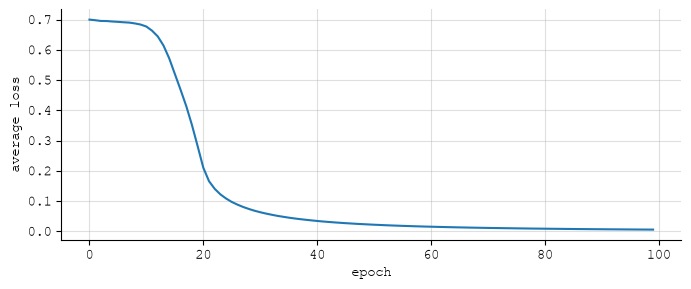

In [167]:
plt.figure(figsize=(8, 3))
plt.plot(tr_history_seq_8_df['epoch'], tr_history_seq_8_df['loss'])
plt.grid(alpha=0.4)
plt.xlabel('epoch'); plt.ylabel('average loss')
sns.despine()

In [61]:
# the Dataset class in pytorch provides an abstraction for accessing a single training example.
# this mains that you could implement your own dataset class to lazily load examples, folr example.
test_dataset = TensorDataset(X_tst, y_tst)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True)

total_loss = 0
correct = 0
total = 0
model.eval()

# don't compute gradients - training so not required.
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        # remove extra dimension
        logits = model(X_batch).squeeze(-1)
        loss = loss_fn(logits, y_batch)
        total_loss += loss.item()

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()

        correct += (preds == y_batch).sum().item() # matching predictions
        total += y_batch.size(0) # number of rows

avg_test_loss = total_loss / len(test_loader)
accuracy = correct / total

print(f'Average loss: {avg_test_loss}')
print(f'Accuracy: {accuracy}')

Average loss: 0.0057633260730654
Accuracy: 1.0


so our model learns to perfectly learn this rule in our sequence. we now turn to use the pre-implemented LSTM model from `pytorch`, and compare this with a standard RNN. we make the problem more difficult with the "remember $n$ prefix" problem. the models will be tasked with recalling the first `n` values from a sequence.

In [118]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, output_size: int):
        super().__init__()

        self.lstm = nn.LSTM(input_size, hidden_size, 1, batch_first=True)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        _, (h, _) = self.lstm(x)

        # final recurrence
        h_final = h[-1]
        logits = self.output(h_final)
        return logits
        

class RNNClassifier(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, output_size: int):
        super().__init__()

        self.rnn = nn.RNN(input_size, hidden_size, 1, batch_first=True)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        _, h = self.rnn(x)

        # final recurrence
        h_final = h[-1]
        logits = self.output(h_final)
        return logits

def p_remember_n_prefix(n_samples: int, n_sequence: int, mem_size: int, train_size=0.8) -> Tuple[torch.tensor, torch.tensor, torch.tensor, torch.tensor]:
    if mem_size > n_sequence:
        raise Exception('p_remember_n_prefix :: targeted memory size is longer than given sequence.')

    sequences = np.random.randint(2, size=(n_samples, n_sequence))

    # get training data and prefix to remember
    X_tr, X_tst = train_test_split(sequences, train_size=train_size, random_state=10)
    y_tr, y_tst = X_tr[:, :mem_size], X_tst[:, :mem_size]

    # turn in
    X_tr, y_tr = torch.tensor(X_tr, dtype=torch.float32), torch.tensor(y_tr, dtype=torch.float32)
    X_tst, y_tst = torch.tensor(X_tst, dtype=torch.float32), torch.tensor(y_tst, dtype=torch.float32)

    X_tr, X_tst = X_tr.unsqueeze(-1), X_tst.unsqueeze(-1)

    return X_tr, y_tr, X_tst, y_tst

we test sequence lengths growing exponentially from `128` with `32` prefix values to remember.

In [148]:
sequence_lengths = [32, 36, 40, 44, 48, 52, 56, 60, 64]
epochs = 2_000
eval_history = []

loss_fn = torch.nn.BCEWithLogitsLoss()

for length in sequence_lengths:
    X_tr, y_tr, X_tst, y_tst = p_remember_n_prefix(4_000, length, 4, train_size=0.25)

    # data loaders and sets
    train_dataset = TensorDataset(X_tr, y_tr)
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    test_dataset = TensorDataset(X_tst, y_tst)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True)

    # set to 4 neurons
    lstm_model = LSTMClassifier(1, 32, 4).to(device)
    rnn_model = RNNClassifier(1, 32, 4).to(device)
    
    optimiser_lstm = torch.optim.Adam(lstm_model.parameters())
    optimiser_rnn = torch.optim.Adam(rnn_model.parameters())

    # train models
    for epoch in range(epochs):
        lstm_model.train()
        rnn_model.train()

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimiser_lstm.zero_grad()
            optimiser_rnn.zero_grad()

            logits_lstm = lstm_model(X_batch).squeeze(-1)
            logits_rnn = rnn_model(X_batch).squeeze(-1)

            loss_lstm = loss_fn(logits_lstm, y_batch)
            loss_rnn = loss_fn(logits_rnn, y_batch)

            loss_lstm.backward()
            optimiser_lstm.step()
            
            loss_rnn.backward()
            optimiser_rnn.step()

    # evaluate models
    lstm_model.eval()
    rnn_model.eval()

    with torch.no_grad():
        eval_dict = {
            'seq_len': length, 'total_loss_lstm': 0, 'total_loss_rnn': 0,
            'correct_lstm': 0, 'correct_rnn': 0, 'total': 0, 'total_bits': 0
        }
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits_lstm, logits_rnn = lstm_model(X_batch).squeeze(-1), rnn_model(X_batch).squeeze(-1)
            loss_lstm, loss_rnn = loss_fn(logits_lstm, y_batch), loss_fn(logits_rnn, y_batch)
            prob_lstm, prob_rnn = torch.sigmoid(logits_lstm), torch.sigmoid(logits_rnn)
            pred_lstm, pred_rnn = (prob_lstm >= 0.5).float(), (prob_rnn >= 0.5).float()

            batch_size = y_batch.size(0)

            eval_dict['total_loss_lstm'] += loss_lstm.item() * batch_size
            eval_dict['total_loss_rnn'] += loss_rnn.item() * batch_size
            eval_dict['correct_lstm'] += (pred_lstm == y_batch).sum().item()
            eval_dict['correct_rnn'] += (pred_rnn == y_batch).sum().item()
            eval_dict['total'] += y_batch.size(0)
            eval_dict['total_bits'] += y_batch.numel()

    eval_history.append(eval_dict)
    print(f'Finished evaluating for sequence length = {length}')

Finished evaluating for sequence length = 32
Finished evaluating for sequence length = 36
Finished evaluating for sequence length = 40
Finished evaluating for sequence length = 44
Finished evaluating for sequence length = 48
Finished evaluating for sequence length = 52
Finished evaluating for sequence length = 56
Finished evaluating for sequence length = 60
Finished evaluating for sequence length = 64


consider the progression of average loss and test accuracy of the RNN and LSTM models as we increase the sequence length. the LSTM dominates the RNN in most sequence lengths (barring noise), as the cell state is able to propagate the information in the first four values. the recurrent neural network does not have a mechanism to do this, and thus the information from the earlier sections gets diluted.

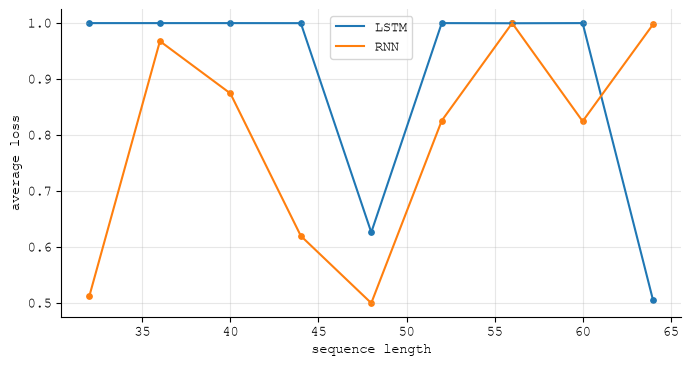

In [166]:
eval_history_df = pd.DataFrame(eval_history)
eval_history_df['average_loss_lstm'] = eval_history_df['total_loss_lstm'] / eval_history_df['total_bits']
eval_history_df['average_loss_rnn'] = eval_history_df['total_loss_rnn'] / eval_history_df['total_bits']
eval_history_df['accuracy_lstm'] = eval_history_df['correct_lstm'] / eval_history_df['total_bits']
eval_history_df['accuracy_rnn'] = eval_history_df['correct_rnn'] / eval_history_df['total_bits']

plt.figure(figsize=(8, 4))

plt.plot(eval_history_df['seq_len'], eval_history_df['accuracy_lstm'] * 100, label='LSTM')
plt.plot(eval_history_df['seq_len'], eval_history_df['accuracy_rnn'] * 100, label='RNN')
plt.scatter(eval_history_df['seq_len'], eval_history_df['accuracy_lstm'] * 100, s=15)
plt.scatter(eval_history_df['seq_len'], eval_history_df['accuracy_rnn'] * 100, s=15)

plt.grid(alpha=0.3)
plt.legend()
plt.xlabel('sequence length')
plt.ylabel('average loss')
sns.despine()